In [ ]:
# Weryfikacja środowiska Pythona
import sys
print(sys.executable)

c:\Users\akepk\spam\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [ ]:
# Odczyt danych i zmiana nazwy kolumny docelowej
df = pd.read_csv("../data/spambase_csv.csv")
if 'class' in df.columns:
    df = df.rename(columns={'class': 'target'})


In [ ]:
# Weryfikacja wymiarów danych
df.shape

(4601, 58)

In [ ]:
# Weryfikacja informacji o danych
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [ ]:
# Weryfikacja pierwszych wierszy danych
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,target
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [8]:

df.columns.tolist()

['word_freq_make',
 'word_freq_address',
 'word_freq_all',
 'word_freq_3d',
 'word_freq_our',
 'word_freq_over',
 'word_freq_remove',
 'word_freq_internet',
 'word_freq_order',
 'word_freq_mail',
 'word_freq_receive',
 'word_freq_will',
 'word_freq_people',
 'word_freq_report',
 'word_freq_addresses',
 'word_freq_free',
 'word_freq_business',
 'word_freq_email',
 'word_freq_you',
 'word_freq_credit',
 'word_freq_your',
 'word_freq_font',
 'word_freq_000',
 'word_freq_money',
 'word_freq_hp',
 'word_freq_hpl',
 'word_freq_george',
 'word_freq_650',
 'word_freq_lab',
 'word_freq_labs',
 'word_freq_telnet',
 'word_freq_857',
 'word_freq_data',
 'word_freq_415',
 'word_freq_85',
 'word_freq_technology',
 'word_freq_1999',
 'word_freq_parts',
 'word_freq_pm',
 'word_freq_direct',
 'word_freq_cs',
 'word_freq_meeting',
 'word_freq_original',
 'word_freq_project',
 'word_freq_re',
 'word_freq_edu',
 'word_freq_table',
 'word_freq_conference',
 'char_freq_%3B',
 'char_freq_%28',
 'char_freq_%5

In [ ]:
# Weryfikacja unikalnych wartości w kolumnie docelowej
df["target"].unique()

array([1, 0])

In [ ]:
# Weryfikacja liczności klas w kolumnie docelowej
df["target"].value_counts()

target
0    2788
1    1813
Name: count, dtype: int64

In [11]:
X = df.drop(columns="target")
y = df["target"]



In [12]:
print("Braki:", df.isna().sum().sum())
print("Maksymalna liczba braków w jednej kolumnie:", df.isnull().sum().max())
print("Duplikaty:", df.duplicated().sum())
print("Liczba cech:", X.shape[1])

Braki: 0
Maksymalna liczba braków w jednej kolumnie: 0
Duplikaty: 391
Liczba cech: 57


Maksymalna liczba braków w jednej kolumnie: 0

Liczba wiadomości w poszczególnych klasach:
target
0    2788
1    1813
Name: count, dtype: int64

Procentowy rozkład klas:
target
0    60.595523
1    39.404477
Name: proportion, dtype: float64


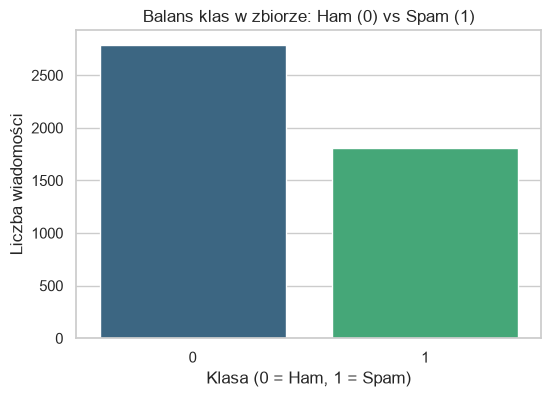

In [ ]:


# Sprawdzenie balansu klas (ile spamu, ile hamu)
print("\nLiczba wiadomości w poszczególnych klasach:")
print(df['target'].value_counts())

print("\nProcentowy rozkład klas:")
# normalize=True zwraca ułamek, mnożymy przez 100 żeby mieć procenty
print(df['target'].value_counts(normalize=True) * 100)

# Wizualizacja balansu klas
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='viridis', hue='target', legend=False)
plt.title('Balans klas w zbiorze: Ham (0) vs Spam (1)')
plt.xlabel('Klasa (0 = Ham, 1 = Spam)')
plt.ylabel('Liczba wiadomości')
plt.show()

--- TOP 10 CECH NAJSILNIEJ ZWIĄZANYCH ZE SPAMEM ---
word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_%24               0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
capital_run_length_total    0.249164
word_freq_our               0.241920
char_freq_%21               0.241888
Name: target, dtype: float64

--- TOP 10 CECH NAJSILNIEJ ZWIĄZANYCH Z NORMALNYMI WIADOMOŚCIAMI (HAM) ---
word_freq_meeting   -0.136615
word_freq_re        -0.140408
word_freq_edu       -0.146138
word_freq_85        -0.149225
word_freq_650       -0.158800
word_freq_labs      -0.171095
word_freq_1999      -0.178045
word_freq_george    -0.183404
word_freq_hpl       -0.232968
word_freq_hp        -0.256723
Name: target, dtype: float64


C:\Users\akepk\AppData\Local\Temp\ipykernel_23924\1701632379.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette=colors)


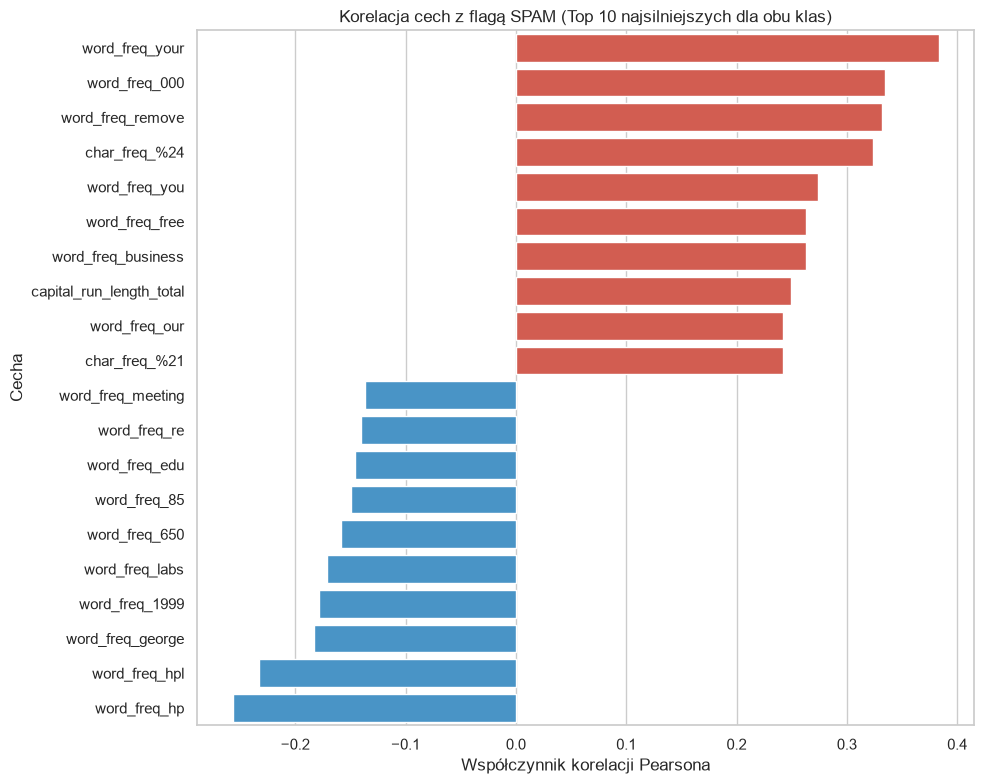

In [14]:
# Obliczenie korelacji wszystkich cech z kolumną 'target'
correlations = df.corr()['target'].sort_values(ascending=False)

# Wyodrębnienie top 10 pozytywnych (cechy spamu) i top 10 negatywnych (cechy hamu)
top_spam_features = correlations[1:11] # Zaczynamy od 1, bo na pozycji 0 jest sam 'target' z korelacją 1.0
top_ham_features = correlations[-10:]

print("--- TOP 10 CECH NAJSILNIEJ ZWIĄZANYCH ZE SPAMEM ---")
print(top_spam_features)

print("\n--- TOP 10 CECH NAJSILNIEJ ZWIĄZANYCH Z NORMALNYMI WIADOMOŚCIAMI (HAM) ---")
print(top_ham_features)

# Kod do wygenerowania wykresu dla Twojej pracy dyplomowej
top_features = pd.concat([top_spam_features, top_ham_features])
plt.figure(figsize=(10, 8))
# Przypisujemy kolor czerwony dla spamu (korelacja > 0) i niebieski dla hamu (korelacja < 0)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_features.values]
sns.barplot(x=top_features.values, y=top_features.index, palette=colors)
plt.title('Korelacja cech z flagą SPAM (Top 10 najsilniejszych dla obu klas)')
plt.xlabel('Współczynnik korelacji Pearsona')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()

#### Wnioski z analizy korelacji:
```
Charakterystyka SPAMU: Typowy spam w tym zbiorze mocno opiera się na słowach związanych z pieniędzmi; 000 często występuje w kwotach, np. $5,000, ofertami (free, business) oraz wezwaniami do akcji (remove - od "click here to remove"). Co ciekawe, char_freq_%24 to po prostu znak dolara $, a char_freq_%21 to wykrzyknik !. Silnym sygnałem spamu jest też długa sekwencja wielkich liter (capital_run_length_total).

 Charakterystyka HAMU (prawdziwych wiadomości): Zbiór Spambase został stworzony w latach 90. przez badaczy z laboratoriów Hewlett-Packard (HP). Dlatego najsilniej z normalnymi mailami korelują słowa takie jak hp, hpl (Hewlett-Packard Labs), george (imię jednego z badaczy - George'a Formana), czy słowa związane z pracą/nauką (meeting, re, edu).
 ```

#### Analiza rozkładów i wartości odstających (Outliers)

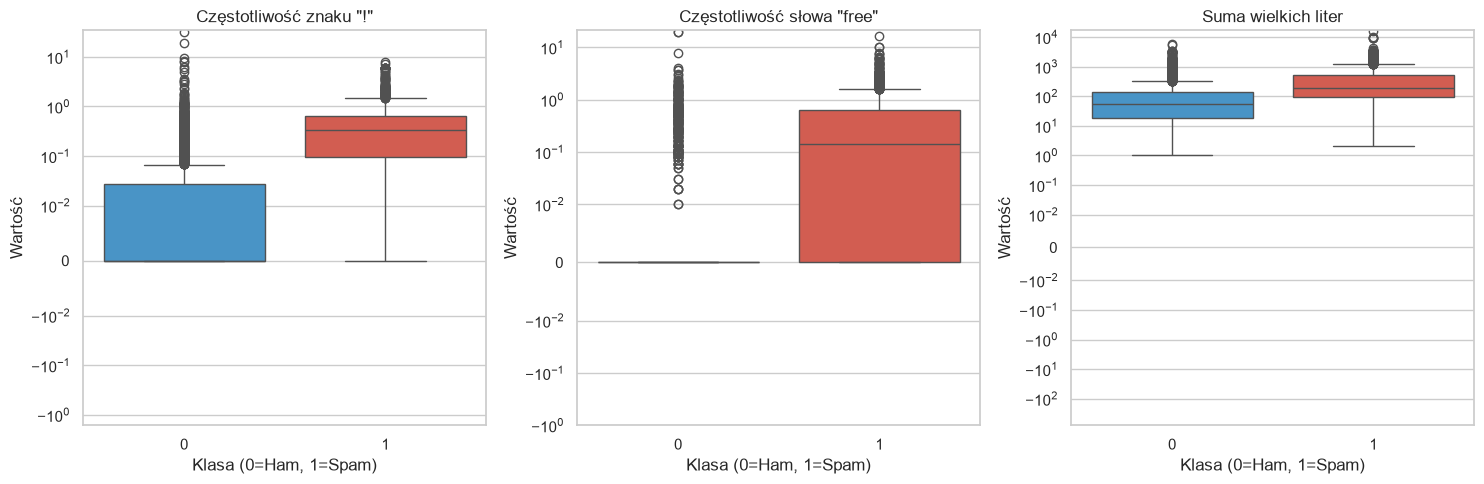

--- STATYSTYKI OPISOWE DLA WYBRANYCH CECH ---


target                                    0             1
char_freq_%21            count  2788.000000   1813.000000
                         mean      0.109984      0.513713
                         std       0.820859      0.744183
                         min       0.000000      0.000000
                         25%       0.000000      0.094000
                         50%       0.000000      0.331000
                         75%       0.027000      0.645000
                         max      32.478000      7.843000
word_freq_free           count  2788.000000   1813.000000
                         mean      0.073587      0.518362
                         std       0.616574      1.013170
                         min       0.000000      0.000000
                         25%       0.000000      0.000000
                         50%       0.000000      0.140000
                         75%       0.000000      0.640000
                         max      20.000000     16.660000
capital_run_length_total count  2788.000000   1813.000000
                         mean    161.470947    470.619415
                         std     355.738403    825.081179
                         min       1.000000      2.000000
                         25%      18.750000     93.000000
                         50%      54.000000    194.000000
                         75%     141.000000    530.000000
                         max    5902.000000  15841.000000

In [15]:
# KROK 4: Wizualizacja rozkładów kluczowych cech
# Wybieramy trzy bardzo zróżnicowane cechy
features_to_plot = ['char_freq_%21', 'word_freq_free', 'capital_run_length_total']
feature_names = ['Częstotliwość znaku "!"', 'Częstotliwość słowa "free"', 'Suma wielkich liter']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(features_to_plot):
    # Rysujemy boxplot, hue załatwia sprawę kolorowania (brak warningów)
    sns.boxplot(
        data=df, 
        x='target', 
        y=feature, 
        ax=axes[i], 
        hue='target',
        palette=['#3498db', '#e74c3c'],
        legend=False
    )
    axes[i].set_title(feature_names[i])
    axes[i].set_xlabel('Klasa (0=Ham, 1=Spam)')
    axes[i].set_ylabel('Wartość')
    
    # Skala logarytmiczna jest tu kluczowa, bo wartości bardzo mocno się różnią
    # Dodajemy małą wartość (np. 0.01), aby uniknąć błędu log(0)
    axes[i].set_yscale('symlog', linthresh=0.01) 

plt.tight_layout()
plt.show()

# Wyświetlamy statystyki opisowe dla tych 3 cech
print("--- STATYSTYKI OPISOWE DLA WYBRANYCH CECH ---")
display(df.groupby('target')[features_to_plot].describe().T)

Mediana (50%) pokazuje prawdę o normalnych mailach: Zwróć uwagę na kwartyle dla normalnych wiadomości (target 0). Mediana (wartość środkowa) dla częstotliwości słowa "free" oraz znaku "!" wynosi dokładnie 0.0. To oznacza, że ponad połowa normalnych maili w ogóle nie zawiera tych elementów. W przypadku spamu (target 1) mediana wynosi odpowiednio 0.14 i 0.33.

Ogromne odchylenie standardowe (std): Popatrz na capital_run_length_total. Dla spamu średnia to około 470, ale odchylenie standardowe wynosi aż 825. Gdy odchylenie standardowe jest niemal dwukrotnie większe od średniej, jest to niezaprzeczalny matematyczny dowód na istnienie silnych wartości odstających (ekstremalnie długich ciągów wielkich liter w pojedynczych wiadomościach).

Ekstremalne maksima (max): Maksymalna długość ciągu wielkich liter w jednej wiadomości spamowej w tym zbiorze wyniosła aż 15 841 znaków.

In [16]:
# Czy identyczne wiadomości/cechy zawsze mają tę samą klasę?
feature_cols = df.columns.drop("target")

conflicting = (
    df.groupby(list(feature_cols))["target"]
      .nunique()
)

print(conflicting.value_counts())

target
1    4204
2       3
Name: count, dtype: int64


In [17]:
feature_cols = df.columns.drop("target")

conflicting_groups = (
    df.groupby(list(feature_cols))["target"]
      .nunique()
)

conflicting_groups = conflicting_groups[
    conflicting_groups > 1
]

print("Liczba konfliktowych zestawów:", len(conflicting_groups))



Liczba konfliktowych zestawów: 3


In [18]:
conflicting_rows = df.merge(
    conflicting_groups.reset_index()[feature_cols],
    on=list(feature_cols),
    how="inner"
)
conflicting_rows

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,target
0,0.00,0.34,0.00,0.0,0.68,0.00,0.68,0.00,0.0,0.34,0.34,0.00,0.00,0.00,0.0,0.34,0.00,1.36,3.42,0.0,2.73,0.0,0.00,0.00,0.34,0.34,0.0,0.0,0.0,0.0,0.0,0.0,0.34,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.048,0.048,0.0,1.411,15,96,1
1,0.36,0.00,1.09,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.72,1.81,0.00,0.0,0.00,0.00,0.00,0.72,0.0,1.09,0.0,0.00,0.72,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.063,0.126,0.0,0.063,0.126,0.0,2.562,35,123,1
2,0.00,0.00,0.00,0.0,0.00,0.05,0.00,0.34,0.0,0.00,0.11,0.81,0.05,0.11,0.0,0.00,0.75,0.00,0.00,0.0,0.00,0.0,0.05,0.00,1.16,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.05,0.0,0.0,0.23,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.283,0.107,0.0,0.000,0.053,0.0,1.864,32,910,1
3,0.36,0.00,1.09,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.72,1.81,0.00,0.0,0.00,0.00,0.00,0.72,0.0,1.09,0.0,0.00,0.72,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.063,0.126,0.0,0.063,0.126,0.0,2.562,35,123,0
4,0.00,0.34,0.00,0.0,0.68,0.00,0.68,0.00,0.0,0.34,0.34,0.00,0.00,0.00,0.0,0.34,0.00,1.36,3.42,0.0,2.73,0.0,0.00,0.00,0.34,0.34,0.0,0.0,0.0,0.0,0.0,0.0,0.34,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.048,0.048,0.0,1.411,15,96,0
5,0.00,0.00,0.00,0.0,0.00,0.05,0.00,0.34,0.0,0.00,0.11,0.81,0.05,0.11,0.0,0.00,0.75,0.00,0.00,0.0,0.00,0.0,0.05,0.00,1.16,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.05,0.0,0.0,0.23,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.283,0.107,0.0,0.000,0.053,0.0,1.864,32,910,0


In [19]:
feature_cols = df.columns.drop("target")

label_counts = (
    df.groupby(list(feature_cols))["target"]
      .nunique()
)

print("Liczba unikalnych zestawów cech:", len(label_counts))
print("Zestawy z jedną etykietą:", (label_counts == 1).sum())
print("Zestawy z konfliktem:", (label_counts > 1).sum())

Liczba unikalnych zestawów cech: 4207
Zestawy z jedną etykietą: 4204
Zestawy z konfliktem: 3


In [20]:
feature_cols = df.columns.drop("target")

# Znajdujemy zestawy cech z więcej niż jedną etykietą
label_counts = (
    df.groupby(list(feature_cols))["target"]
      .nunique()
)

conflicting_features = label_counts[label_counts > 1].index

# Usuwamy wszystkie rekordy należące do konfliktowych zestawów
df_no_conflicts = (
    df.set_index(list(feature_cols))
      .drop(index=conflicting_features)
      .reset_index()
)

print("Przed:", len(df))
print("Po usunięciu konfliktów:", len(df_no_conflicts))

Przed: 4601
Po usunięciu konfliktów: 4595


In [21]:
# Usuwamy duplikaty
df_clean = df_no_conflicts.drop_duplicates()

print("Po deduplikacji:", len(df_clean))

Po deduplikacji: 4204


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213015,1.290575,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.280656,0.504143,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312223,0.672513,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.095901,0.273824,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090067,0.278616,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.000,0.000,0.160,18.180


### Najważniejsza obserwacja: 
* większość cech ma medianę równą 0. Czyli w większości wiadomości dane słowo/kategoria słowa w ogóle nie występuje.
* wiele zmiennych ma bardzo duże maksimum w stosunku do mediany. To sugeruje silnie skośne rozkłady i potencjalne wartości odstające np
  * capital_run_length_average median = 2.276 max    = 1102.5
  * capital_run_length_longest median = 15 max    = 9989

To sugeruje silnie skośne rozkłady i potencjalne wartości odstające.

To będzie ważne później szczególnie dla:
* KNN,
* SVM,
* Logistic Regression,
* PCA,
* Naive Bayes.

Modele drzewiaste, czyli Random Forest, XGBoost i LightGBM, są mniej wrażliwe na skalę cech.

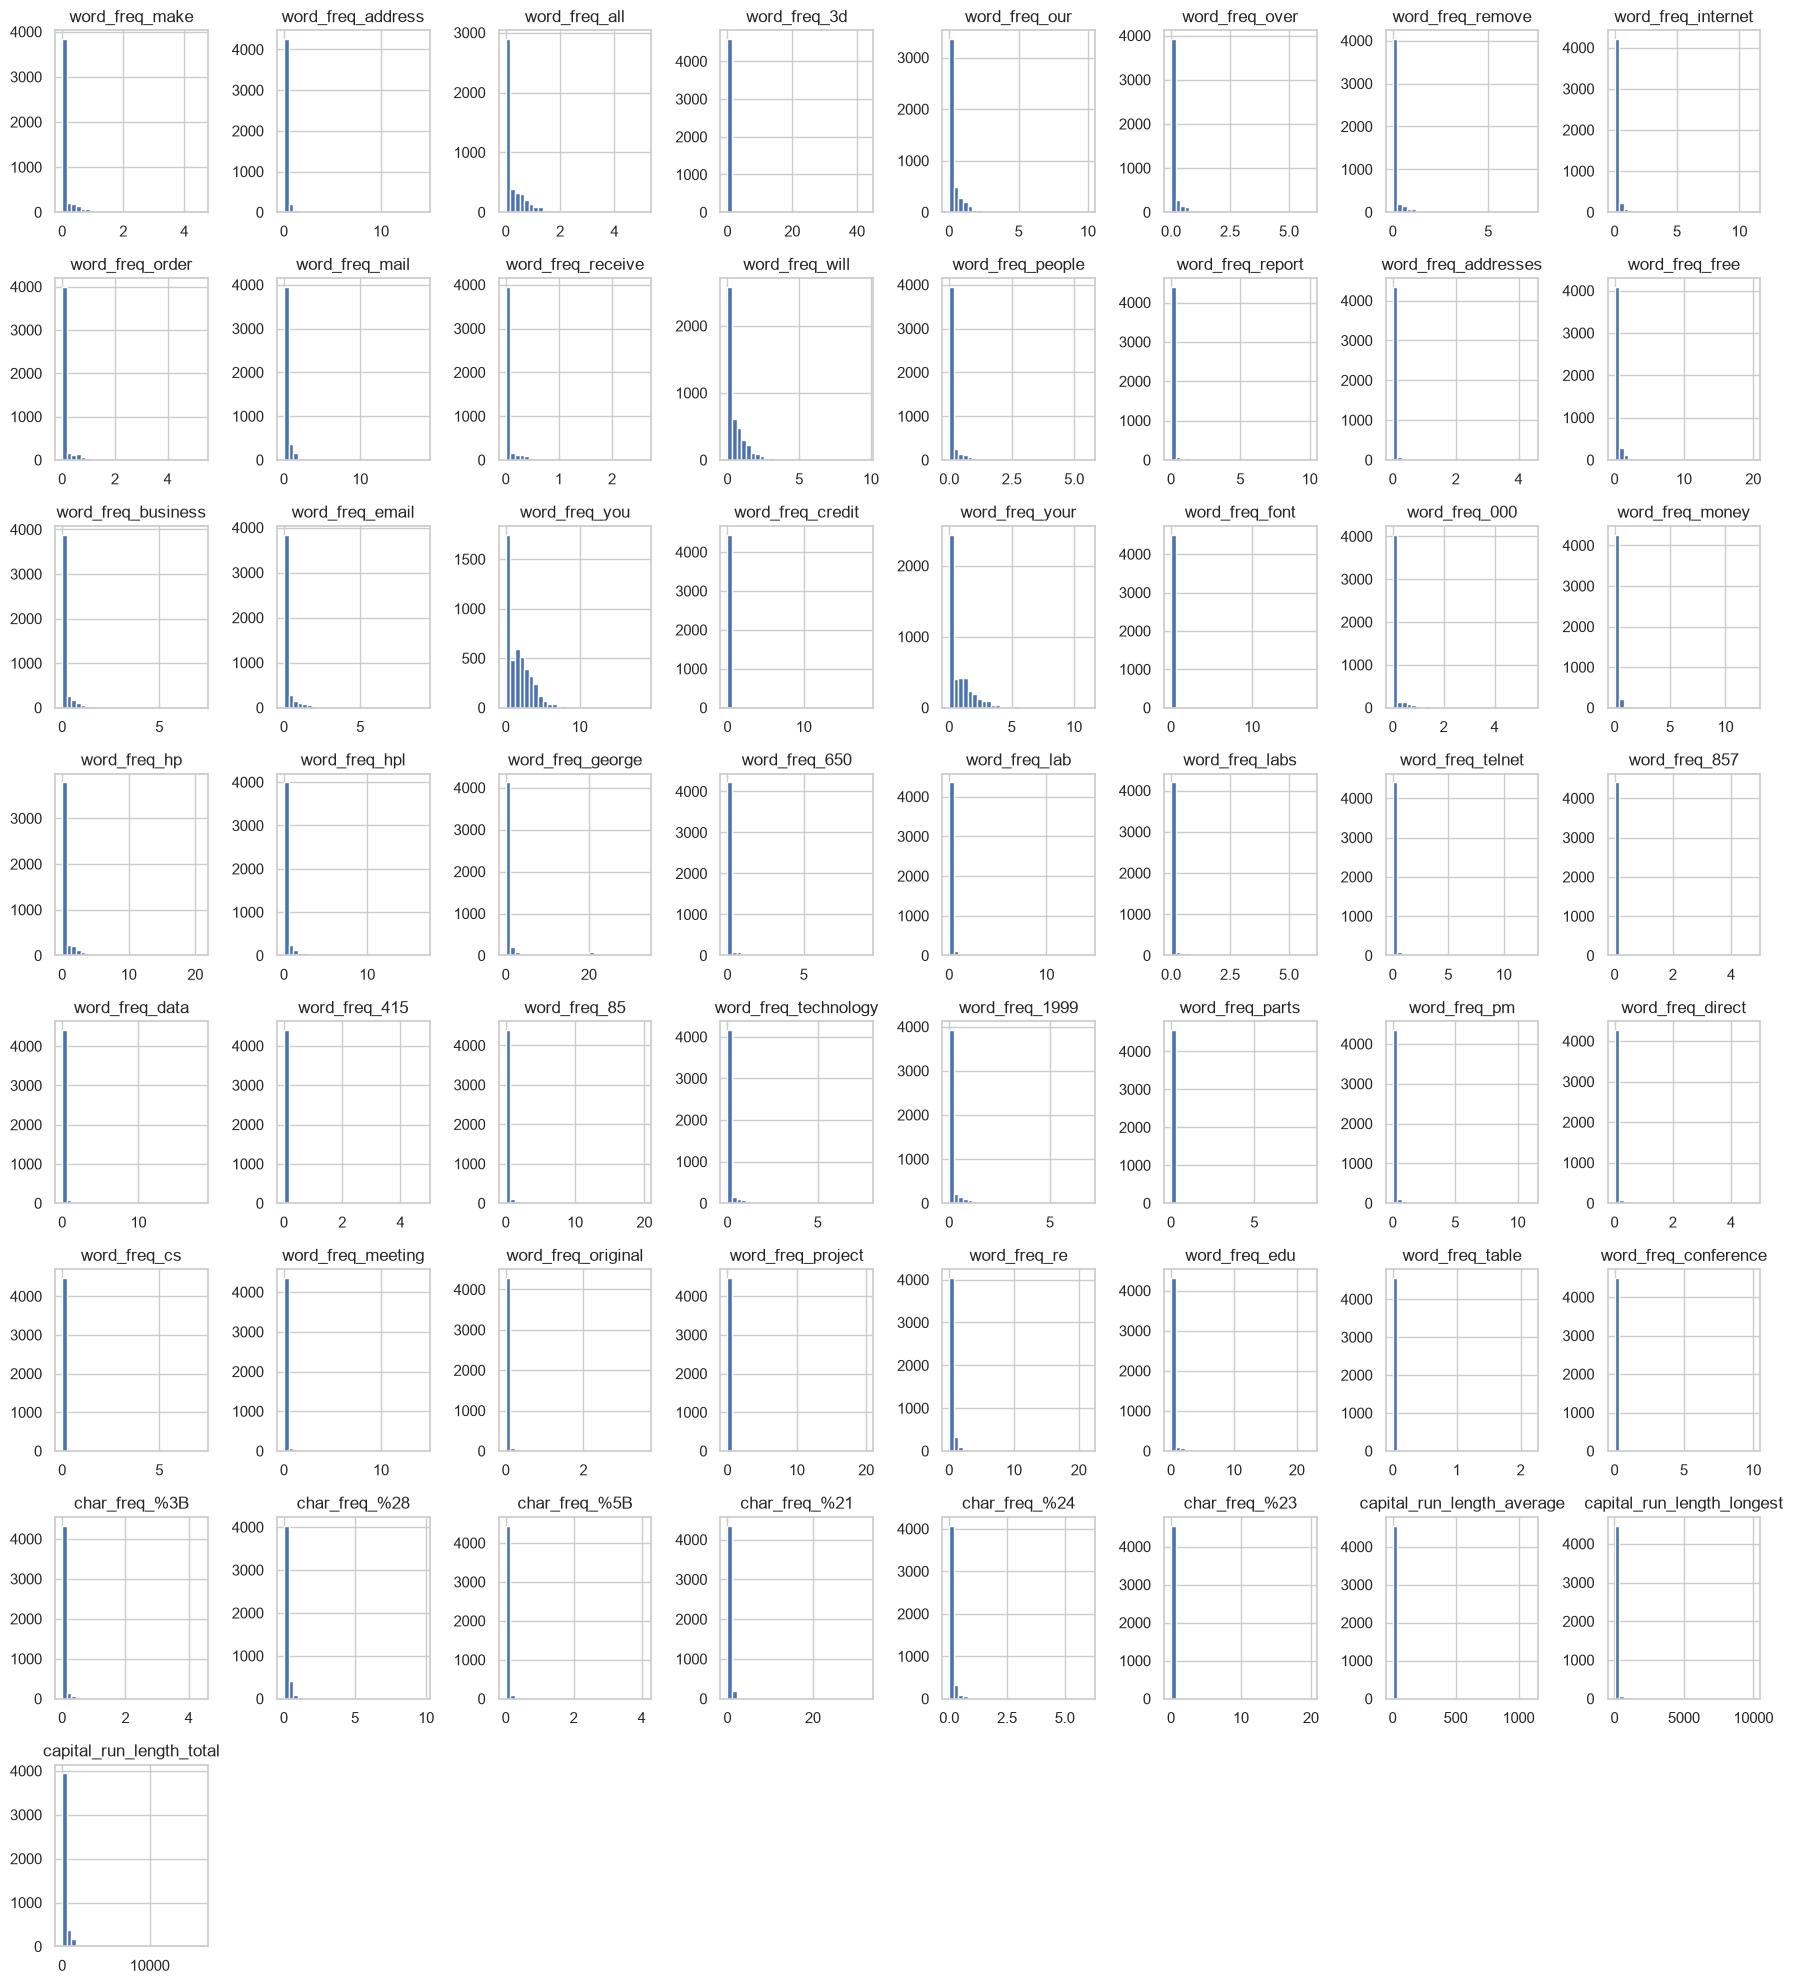

In [23]:
X.hist(
    figsize=(18, 20),
    bins=30
)
plt.tight_layout()
plt.show()


Większość cech jest mocno prawoskośna — ogromna liczba obserwacji skupia się przy 0, a następnie występuje długi ogon.
Występują wartości odstające, szczególnie widoczne dla:
* capital_run_length_average
* capital_run_length_longest
* capital_run_length_total
* word_freq_3d
* word_freq_george
* word_freq_free
* word_freq_you
* word_freq_your


In [24]:
# rozklad klas %

df["target"].value_counts(normalize=True) * 100

target
0    60.595523
1    39.404477
Name: proportion, dtype: float64

# Eksploracyjna analiza danych (EDA) dla zbioru spam

Przeprowadzimy następujące kroki:
- wczytanie danych i sprawdzenie kształtu zbioru,
- analiza rozkładu klasy `target` (spam / nie-spam),
- sprawdzenie braków i typów danych,
- wskazanie cech o najsilniejszej różnicy między klasami,
- wizualizacja korelacji i dystrybucji najważniejszych cech.


In [50]:
# Szybkie sprawdzenie danych
print('Kształt danych:', df.shape)
print('\nUnikalne wartości celu:')
print(df['target'].value_counts())
print('\nBraki danych ogółem:', df.isna().sum().sum())
print('\nTypy danych:')
print(df.dtypes.value_counts())

Kształt danych: (4601, 58)

Unikalne wartości celu:
target
0    2788
1    1813
Name: count, dtype: int64

Braki danych ogółem: 0

Typy danych:
float64    55
int64       3
Name: count, dtype: int64


C:\Users\akepk\AppData\Local\Temp\ipykernel_23924\2901622422.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


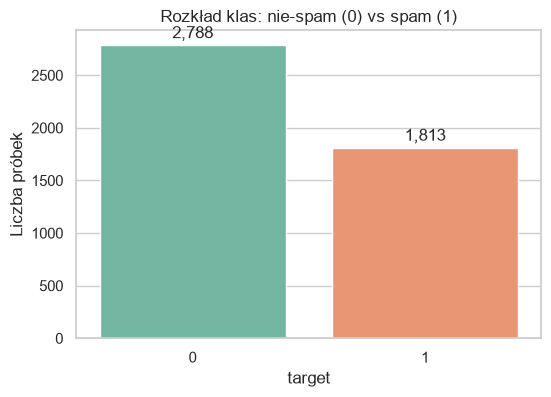


Proporcja klas:
target
0    60.60%
1    39.40%
Name: proportion, dtype: str


In [51]:
# Rozkład klas w zbiorze
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Rozkład klas: nie-spam (0) vs spam (1)')
plt.xlabel('target')
plt.ylabel('Liczba próbek')
for p in plt.gca().patches:
    plt.gca().annotate(format(int(p.get_height()), ','),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.show()
print('\nProporcja klas:')
print(df['target'].value_counts(normalize=True).map('{:.2%}'.format))

Top 12 cech o największej różnicy średnich między klasami:
target                               0           1    abs_diff
capital_run_length_total    161.470947  470.619415  309.148468
capital_run_length_longest   18.214491  104.393271   86.178780
capital_run_length_average    2.377301    9.519165    7.141864
word_freq_george              1.265265    0.001550    1.263716
word_freq_you                 1.270341    2.264539    0.994199
word_freq_your                0.438702    1.380370    0.941668
word_freq_hp                  0.895473    0.017479    0.877994
word_freq_free                0.073587    0.518362    0.444775
word_freq_hpl                 0.431994    0.009173    0.422822
char_freq_%21                 0.109984    0.513713    0.403729
word_freq_our                 0.181040    0.513955    0.332915
word_freq_re                  0.415760    0.125091    0.290669


C:\Users\akepk\AppData\Local\Temp\ipykernel_23924\2682955415.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='abs_diff', y=means.head(12).index, data=means.head(12).reset_index(), palette='rocket')


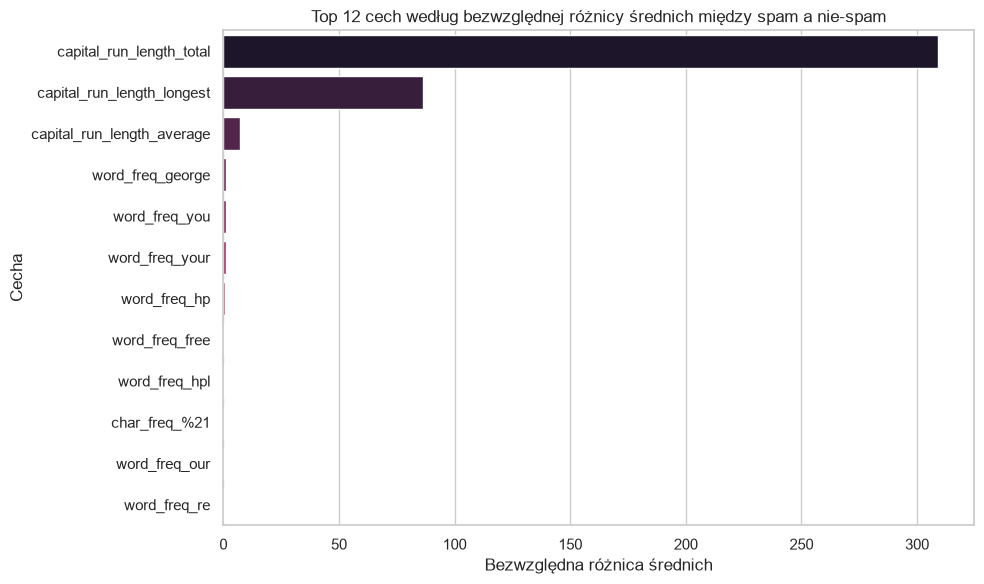

In [52]:
# Najważniejsze cechy na podstawie różnicy średnich między klasami
means = df.groupby('target').mean().T
means['abs_diff'] = (means[1] - means[0]).abs()
means = means.sort_values('abs_diff', ascending=False)

top_features = means.head(12).index.tolist()
print('Top 12 cech o największej różnicy średnich między klasami:')
print(means.head(12))
#print(means['0', '1', 'abs_diff'].head(12))

plt.figure(figsize=(10, 6))
sns.barplot(x='abs_diff', y=means.head(12).index, data=means.head(12).reset_index(), palette='rocket')
plt.title('Top 12 cech według bezwzględnej różnicy średnich między spam a nie-spam')
plt.xlabel('Bezwzględna różnica średnich')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()

Top 10 cech skorelowanych z target:
target                      1.000000
word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_%24               0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
word_freq_hp                0.256723
capital_run_length_total    0.249164
word_freq_our               0.241920
Name: target, dtype: float64


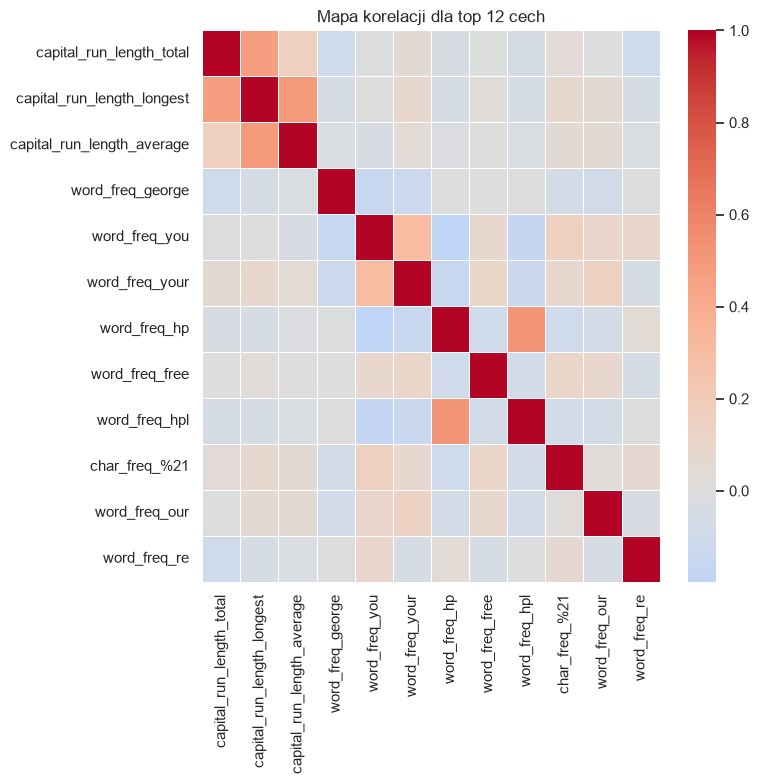

In [53]:
# Korelacja cech z celem oraz wybrane cechy do wizualizacji
corr = df.corr()
target_corr = corr['target'].abs().sort_values(ascending=False)
print('Top 10 cech skorelowanych z target:')
print(target_corr.head(11))

plt.figure(figsize=(8, 8))
sns.heatmap(corr.loc[top_features].loc[:, top_features], cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Mapa korelacji dla top 12 cech')
plt.tight_layout()
plt.show()


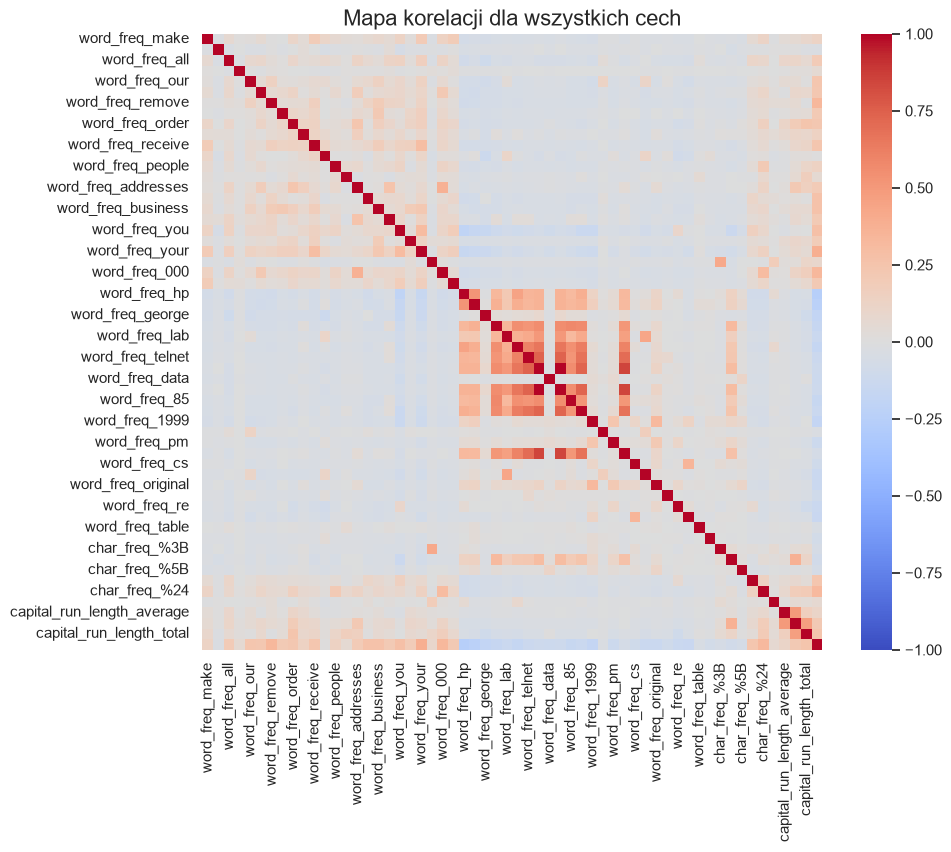

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title('Mapa korelacji dla wszystkich cech', fontsize=16)
plt.show()

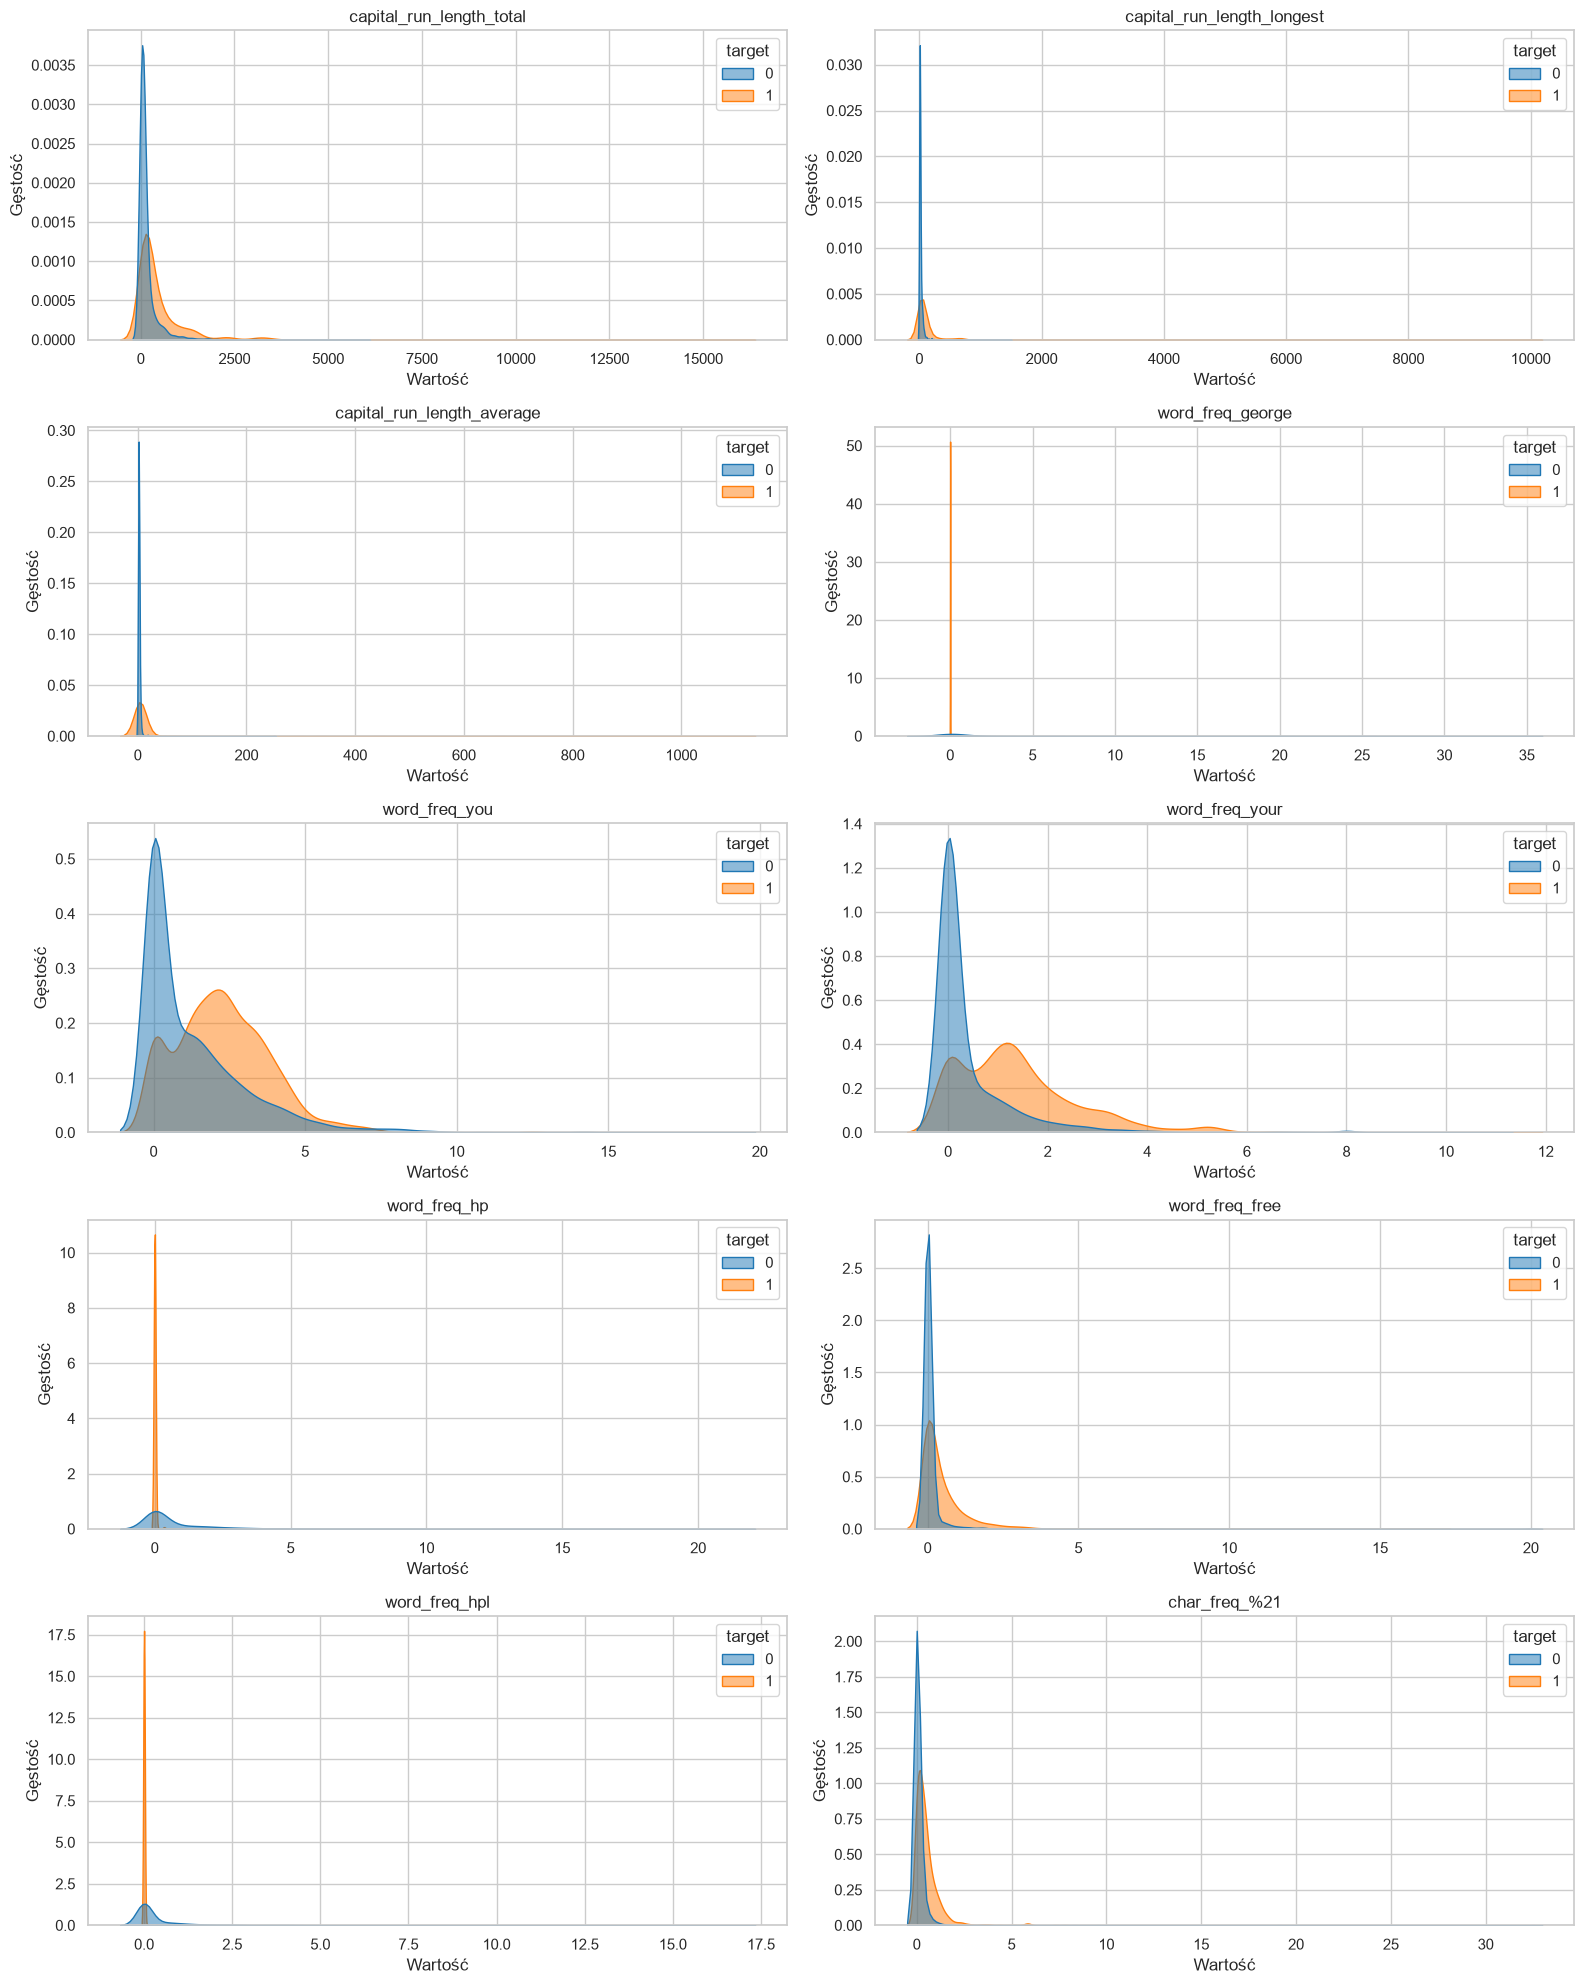

In [55]:
# Dystrybucje najważniejszych cech względem klasy
plt.figure(figsize=(16, 20))
for idx, feature in enumerate(top_features[:10], 1):
    ax = plt.subplot(5, 2, idx)
    sns.kdeplot(data=df, x=feature, hue='target', common_norm=False, fill=True, alpha=0.5, palette=['tab:blue', 'tab:orange'])
    ax.set_title(feature)
    ax.set_xlabel('Wartość')
    ax.set_ylabel('Gęstość')

plt.tight_layout()
plt.show()